# Создание модели для предсказания массы морских черепах

## Постановка задачи машинного обучения

В рамках выполнения проекта необходимо создать модель для предсказания массы морских черепах. Так как предсказывается число - задача является задачей регрессии. 

Причиной создания модели служит отсутствие возможности взвешивания тяжелых черепах в естественных условиях, а также риск нанесения травм животным в процессе. Для решения указанных проблем необходимо разработать модель линейной регресии, которая будет использовать габариты и другие данные для предсказания массы черепах. 

Поле `weight` (масса черепахи в килограммах) является целевой переменной.

В качестве метрик планируется использовать:
- MAE;
- MSE;
- MAPE;
- R^2.

Проект будет считать успешным, если значение метрики `MAE` будет в пределах 5 килограммов на валидационной и тестовой выборках, коэффициент детерминации будет не меньше 0.97, метрики `MSE` и `MAPE` будут как можно ниже.

## Подключение и настройка библиотек

В блоке кода ниже, помимо уже указанных библиотек, импортируйте все остальные, которые планируете использовать для проекта.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from phik import phik_matrix
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression, Ridge, SGDRegressor, Lasso

## Загрузка датасета

Загрузим данные датасета из файла.

In [3]:
try:
    df = pd.read_csv('/datasets/turtles.csv', sep='\t', decimal=',') 
except:
    df = pd.read_csv('https://code.s3.yandex.net/datasets/turtles.csv', sep='\t', decimal=',') 

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8861 entries, 0 to 8860
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   8861 non-null   int64  
 1   binomial_name        8812 non-null   str    
 2   registration number  8832 non-null   str    
 3   shell_length         8774 non-null   float64
 4   shell_width          8861 non-null   int64  
 5   head_length          8715 non-null   float64
 6   head_width           8715 non-null   float64
 7   flipper_length_1     8861 non-null   int64  
 8   flipper_width_1      8861 non-null   int64  
 9   flipper_length_2     8861 non-null   int64  
 10  flipper_width_2      8861 non-null   int64  
 11  flipper_length_3     8760 non-null   float64
 12  flipper_width_3      8760 non-null   float64
 13  flipper_length_4     8760 non-null   float64
 14  flipper_width_4      8760 non-null   float64
 15  circle_count         8861 non-null   int64  
 16 

In [5]:
start_shape_from_download = df.shape
start_shape_from_download

(8861, 20)

In [6]:
df.head()

,id,binomial_name,registration number,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,timestamp,weight
0,20438,Caretta caretta,d89af72662f49ece4d09dec75a8b0166,700.0,381,112.0,82.0,356,205,331,185,270.0,180.0,273.0,144.0,63,3.0,NaN,1703159226,87.687
1,19034,Lepidochelys olivacea,1579c64777de4db1c16e8b7b0d19c45e,341.0,295,65.0,48.0,216,190,229,186,164.0,182.0,180.0,149.0,0,1.0,1.0,1689428175,26.949
2,24689,LEPIDOCHELYS OLIVACEA,bfcec01187569615087e4d777c44985a,408.0,343,71.0,70.0,308,224,285,232,264.0,179.0,268.0,176.0,0,3.0,NaN,1745783111,30.016
3,17945,Lepidochelys Olivacea,2c159675aa28f0ea566fce2090bf4c82,512.0,432,98.0,95.0,334,317,364,284,NaN,NaN,NaN,NaN,3,4.0,1.0,1677757151,33.917
4,24543,lepidochelys olivacea,ecd22499761e2ac56a6d8eb765ec566d,408.0,307,50.0,54.0,280,168,269,218,199.0,165.0,209.0,180.0,0,4.0,1.0,1744455613,28.511


Приведем столбец `registration number` к змеиному регистру.

In [7]:
df = df.rename(columns={'registration number': 'registration_number'})

In [8]:
df.columns

Index(['id', 'binomial_name', 'registration_number', 'shell_length',
       'shell_width', 'head_length', 'head_width', 'flipper_length_1',
       'flipper_width_1', 'flipper_length_2', 'flipper_width_2',
       'flipper_length_3', 'flipper_width_3', 'flipper_length_4',
       'flipper_width_4', 'circle_count', 'measure_count', 'shell_crack',
       'timestamp', 'weight'],
      dtype='str')

В выгрузке имеются все столбцы из условия. Проверим общие сведения о данных.

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8861 entries, 0 to 8860
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   8861 non-null   int64  
 1   binomial_name        8812 non-null   str    
 2   registration_number  8832 non-null   str    
 3   shell_length         8774 non-null   float64
 4   shell_width          8861 non-null   int64  
 5   head_length          8715 non-null   float64
 6   head_width           8715 non-null   float64
 7   flipper_length_1     8861 non-null   int64  
 8   flipper_width_1      8861 non-null   int64  
 9   flipper_length_2     8861 non-null   int64  
 10  flipper_width_2      8861 non-null   int64  
 11  flipper_length_3     8760 non-null   float64
 12  flipper_width_3      8760 non-null   float64
 13  flipper_length_4     8760 non-null   float64
 14  flipper_width_4      8760 non-null   float64
 15  circle_count         8861 non-null   int64  
 16 

Типы данных выглядят корректно, за исключением типа данных и формата столбца `timestamp`, который должен содержать данные о времени. Остальные типы данных являются допустимыми.

В более чем половине столбцов содержатся пропуски.

In [10]:
print(f'Количество пропусков в столбцах: \n\n{df.isna().sum()}')

Количество пропусков в столбцах: 

id                        0
binomial_name            49
registration_number      29
shell_length             87
shell_width               0
head_length             146
head_width              146
flipper_length_1          0
flipper_width_1           0
flipper_length_2          0
flipper_width_2           0
flipper_length_3        101
flipper_width_3         101
flipper_length_4        101
flipper_width_4         101
circle_count              0
measure_count           264
shell_crack            6685
timestamp                 0
weight                   19
dtype: int64


Прежде чем обработывать пропуски и типы данных, отберем в пункте 4.1 проекта нужный нам тип черепах и сделаем предположение, какие признаки будут полезны для модели. Возможно, обработка не потребуется.

## Исследовательский анализ данных

### 4.1 Анализ, какие виды черепах представлены в датасете.

Рассмотрим типы черепах из датасета.

In [11]:
print(f'Кол-во уникальных типов черепах: {df["binomial_name"].nunique()}')
print(f'Уникальные типы черепах: \n{list(df["binomial_name"].unique())}')

Кол-во уникальных типов черепах: 23
Уникальные типы черепах: 
['Caretta caretta', 'Lepidochelys olivacea', 'LEPIDOCHELYS OLIVACEA', 'Lepidochelys Olivacea', 'lepidochelys olivacea', 'Chelonia mydas', 'ERETMOCHELYS IMBRICATA', 'Eretmochelys imbricata', 'Dermochelys coriacea', 'caretta caretta', 'CARETTA CARETTA', 'chelonia mydas', 'Chelonia Mydas', 'CHELONIA MYDAS', 'Dermochelys Coriacea', 'eretmochelys imbricata', nan, 'Caretta Caretta', 'lepidochelys kempii', 'Lepidochelys kempii', 'Eretmochelys Imbricata', 'dermochelys coriacea', 'Lepidochelys Kempii', 'DERMOCHELYS CORIACEA']


Можно увидеть, что среди типов черепах есть дублирующиеся значения, имеющие, например, разный регистр написания ("Caretta caretta", "caretta caretta", "CARETTA CARETTA" и т.д.). Приведем все названия к одному регистру.

In [12]:
df['binomial_name'] = df['binomial_name'].str.lower()

In [13]:
print(f'Кол-во уникальных типов черепах: {df["binomial_name"].nunique()}')
print(f'Уникальные типы черепах: \n{list(df["binomial_name"].unique())}')

Кол-во уникальных типов черепах: 6
Уникальные типы черепах: 
['caretta caretta', 'lepidochelys olivacea', 'chelonia mydas', 'eretmochelys imbricata', 'dermochelys coriacea', nan, 'lepidochelys kempii']


Остались уникальные виды черепах.

### 4.2 Отбор записей с черепахами вида "Chelonia mydas".

Отберем записи с определенным видом черепах.

In [14]:
df = df[df['binomial_name'] == 'chelonia mydas']

In [15]:
start_shape = df.shape
print(f'Start shape:{start_shape_from_download}\nCurrent shape:{start_shape}')

Start shape:(8861, 20)
Current shape:(2829, 20)


При отборе кол-во строк уменьшилось почти в 4 раза.

### 4.3 Отбор признаков.

Рассмотрим, какими признаками мы располагаем, и как выглядят их значения.

In [16]:
df.columns

Index(['id', 'binomial_name', 'registration_number', 'shell_length',
       'shell_width', 'head_length', 'head_width', 'flipper_length_1',
       'flipper_width_1', 'flipper_length_2', 'flipper_width_2',
       'flipper_length_3', 'flipper_width_3', 'flipper_length_4',
       'flipper_width_4', 'circle_count', 'measure_count', 'shell_crack',
       'timestamp', 'weight'],
      dtype='str')

In [17]:
df.head()

,id,binomial_name,registration_number,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,timestamp,weight
8,25241,chelonia mydas,0d05dca974d9f624d9c9f8e38817f827,742.0,652,118.0,147.0,411,386,507,389,414.0,368.0,311.0,325.0,66,4.0,1.0,1751228603,56.352
11,20099,chelonia mydas,36e7d3b61a0d557e45ad4b39bb2ec512,1336.0,1318,207.0,248.0,845,704,661,768,587.0,686.0,661.0,585.0,111,2.0,5.0,1699913950,154.074
16,18213,chelonia mydas,cbb98eb064c1dcefd1a009b21656500f,1010.0,926,216.0,156.0,562,488,529,432,467.0,434.0,553.0,463.0,76,1.0,NaN,1680303901,87.695
20,20656,chelonia mydas,0da9da7f4ed73816b8967c7fe87fc4f5,703.0,606,NaN,NaN,355,382,411,340,302.0,355.0,314.0,283.0,62,3.0,1.0,1705325532,51.182
21,20839,chelonia mydas,8c20d754391001ef4cda77701123f4bc,982.0,940,187.0,157.0,518,557,545,463,497.0,511.0,541.0,479.0,103,2.0,NaN,1707227368,92.707


Цель проекта - разработать модель для предсказания массы морских черепах. С учетом этого сделаем выводы о признаках, которые нам не помогут:
- удалим идентификационные признаки `id`, `registration_number`;
- удалим признак `binomial_name`, так как в датафрейме остался всего один тип черепах;
- на массу черепахи вряд ли оказывает влияние признак `timestamp` - время внесения данных о черепахи - его так же удалим;
- признак `measure_count` так же является сторонним - на массу черепахи не влияет кол-во измерений по модели компьютерного зрения.

Остальные признаки могут оказать влияние.

In [18]:
df = df.drop(labels=['id', 'registration_number', 'binomial_name', 'timestamp', 'measure_count'], axis=1)

Рассмотрим оставшийся датафрейм после удаления признаков.

In [19]:
df.head()

,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,shell_crack,weight
8,742.0,652,118.0,147.0,411,386,507,389,414.0,368.0,311.0,325.0,66,1.0,56.352
11,1336.0,1318,207.0,248.0,845,704,661,768,587.0,686.0,661.0,585.0,111,5.0,154.074
16,1010.0,926,216.0,156.0,562,488,529,432,467.0,434.0,553.0,463.0,76,NaN,87.695
20,703.0,606,NaN,NaN,355,382,411,340,302.0,355.0,314.0,283.0,62,1.0,51.182
21,982.0,940,187.0,157.0,518,557,545,463,497.0,511.0,541.0,479.0,103,NaN,92.707


### 4.4 Работа с пропусками.

Проверим наличие и количество пропусков в данных.

In [20]:
df.isna().sum()

shell_length          35
shell_width            0
head_length           39
head_width            39
flipper_length_1       0
flipper_width_1        0
flipper_length_2       0
flipper_width_2        0
flipper_length_3      31
flipper_width_3       31
flipper_length_4      31
flipper_width_4       31
circle_count           0
shell_crack         2152
weight                 3
dtype: int64

Проверям, встречаются ли пропуски вместе.

In [21]:
df[df['head_length'].isna()]['head_width'].isna().sum()

np.int64(39)

Можно понять, что для 39 строк в целом нет информации о замерах головы черепахи. Если удалять строки с пропусками в `head_length`, то тогда будут автоматически удалены и строки с пропусками в `head_width`.

In [22]:
print(f'''flipper_length_3 - flipper_width_3: {df[df["flipper_length_3"].isna()]["flipper_width_3"].isna().sum()}
flipper_length_3 - flipper_length_4: {df[df["flipper_length_3"].isna()]["flipper_length_4"].isna().sum()}
flipper_length_3 - flipper_width_4: {df[df["flipper_length_3"].isna()]["flipper_width_4"].isna().sum()}''')

flipper_length_3 - flipper_width_3: 31
flipper_length_3 - flipper_length_4: 31
flipper_length_3 - flipper_width_4: 31


То же самое можно сказать и о замерах третьей и четвертой ласт черепах. Одновременно присутствуют в одних и тех же строках пропуски в измерениях длины и ширины 3 и 4 ласт.

Длина панциря (`shell_length`) не имеет явных совпадений в пропусках с другими признаками.

Имеется 3 пропуска в столбце с целевой переменной (`weight`).

Очень много пропусков содержится в столбце `shell_crack`.

Проверим процент пропусков для измерений головы черепахи и измерений 3 и 4 ласт.

In [23]:
print(f'''Пропусков для измерений головы: {round(df["head_length"].isna().sum() / df.shape[0] * 100, 2)}%
Пропусков для измерений 3-ей и 4-ой ласт: {round(df["flipper_length_3"].isna().sum() / df.shape[0] * 100, 2)}%
Пропусков для длины панциря: {round(df["shell_length"].isna().sum() / df.shape[0] * 100, 2)}%''')

Пропусков для измерений головы: 1.38%
Пропусков для измерений 3-ей и 4-ой ласт: 1.1%
Пропусков для длины панциря: 1.24%


Процент исследуемых пропусков мал. К тому же некоторве строки могут содержать сразу несколько типов пропусков. Удалим строки с пропусками в этих столбцах.

In [24]:
df = df.dropna(subset=['head_length', 'flipper_length_3', 'shell_length', 'weight'])
print(f'Удалено {start_shape[0] - df.shape[0]} строк, {round((start_shape[0] - df.shape[0]) / start_shape[0] * 100, 2)}% данных')

Удалено 105 строк, 3.71% данных


Было удалено умеренное количество строк. Информация о пропусках после удаления представлена ниже.

In [25]:
df.isna().sum()

shell_length           0
shell_width            0
head_length            0
head_width             0
flipper_length_1       0
flipper_width_1        0
flipper_length_2       0
flipper_width_2        0
flipper_length_3       0
flipper_width_3        0
flipper_length_4       0
flipper_width_4        0
circle_count           0
shell_crack         2073
weight                 0
dtype: int64

На данном этапе сложно сделать предположение о том, что делать с пропусками в `shell_crack`. Посмотрим, есть ли зависимость между этой переменной и целевой.

<Axes: title={'center': 'Заивисмость между наличием трещины в панцире и массой черепахи'}, xlabel='Наличие трещин панциря', ylabel='Масса черепахи'>

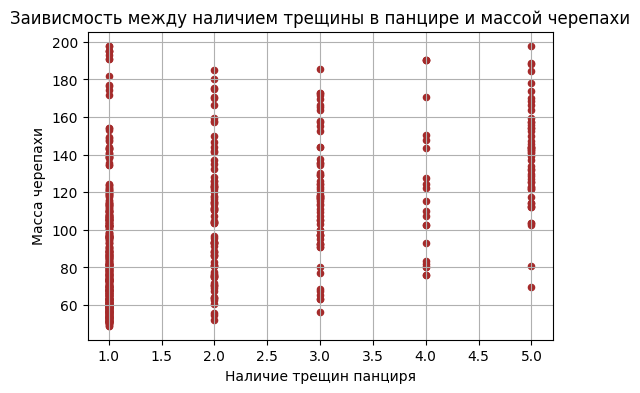

In [26]:
df.plot(kind='scatter', x='shell_crack', y='weight', color='brown', figsize=(6, 4), xlabel='Наличие трещин панциря', ylabel='Масса черепахи', title='Заивисмость между наличием трещины в панцире и массой черепахи', grid=True)

По графику можно понять, что линейной зависимости между наличием трещин и целевой переменной нет, а так как этот столбец содержит примерно 25% от всех данных пропусков - не будем рассматривать этот столбец в качестве признака для модели и удалим его.

In [27]:
df = df.drop(labels=['shell_crack'], axis=1)

In [28]:
df.isna().sum().sum()

np.int64(0)

Все пропуски в данных были обработаны. 

### 4.5 Работа с дубликатами.

Проведем поиск явных дубликатов.

In [29]:
df.duplicated().sum()

np.int64(328)

Удалим явные дубликаты.

In [30]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

Для неявных дубликатов:
- нет категориальных данных, с регистром, способом написания и т.д. которых могла быть проведена работа;
- нет комбинаций признаков, которые могли быть распознаны как дубликаты.

Значит работа с дубликатами на этом завершена.

### 4.6 Работа с распределениями признаков.

In [31]:
df.columns

Index(['shell_length', 'shell_width', 'head_length', 'head_width',
       'flipper_length_1', 'flipper_width_1', 'flipper_length_2',
       'flipper_width_2', 'flipper_length_3', 'flipper_width_3',
       'flipper_length_4', 'flipper_width_4', 'circle_count', 'weight'],
      dtype='str')

Перед началом анализа распределений вспомним, что некоторые величины в полях с габаритами некорректно отображаются, потому что их дополнительно умножили на десять. Попробуем понять, для каких признаков это актуально (где есть выбросы в правой части графика).

Для начала рассмотрим некоторые статистические показатели для каждого признака.

In [32]:
df.describe().loc[['mean', 'min', 'max', '50%']]

,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,weight
mean,1048.943239,946.114357,169.601419,183.053005,612.154424,549.551336,611.876461,550.731636,487.274624,440.653172,489.369783,441.166945,80.904007,96.051661
min,645.000000,564.000000,87.000000,96.000000,339.000000,245.000000,327.000000,276.000000,282.000000,231.000000,254.000000,243.000000,29.000000,0.000000
max,12840.000000,11550.000000,328.000000,364.000000,1147.000000,1072.000000,1049.000000,997.000000,934.000000,837.000000,877.000000,806.000000,141.000000,199.961000
50%,980.500000,890.000000,163.000000,176.000000,588.000000,528.000000,591.000000,533.500000,473.000000,426.000000,473.000000,423.000000,80.000000,88.178500


Значения для всех признаков, кроме `shell_length` и `shell_width` выглядят допустимыми. У этих же столбцов при медиане и среднем значении около 1000 у `shell_length` и около 900 у `shell_width` максимальные значения находятся около 13000 и 12000 соот-но.

Вероятно, это те самые описки, полученные случайным умножением значений на 10. По сути, если поделить их на 10, мы получим корректные значения, но нельзя быть уверенным при делении, правильное ли мы значение идентифицировали как умноженное на 10. Возможно, это просто был выброс. Проверим гистограммы и диаграмму размаха, чтобы определиться, что с ними делать.

In [33]:
count_signs = len(df.columns) - 1
count_signs

13

Построим гистограммы 12 признаков.

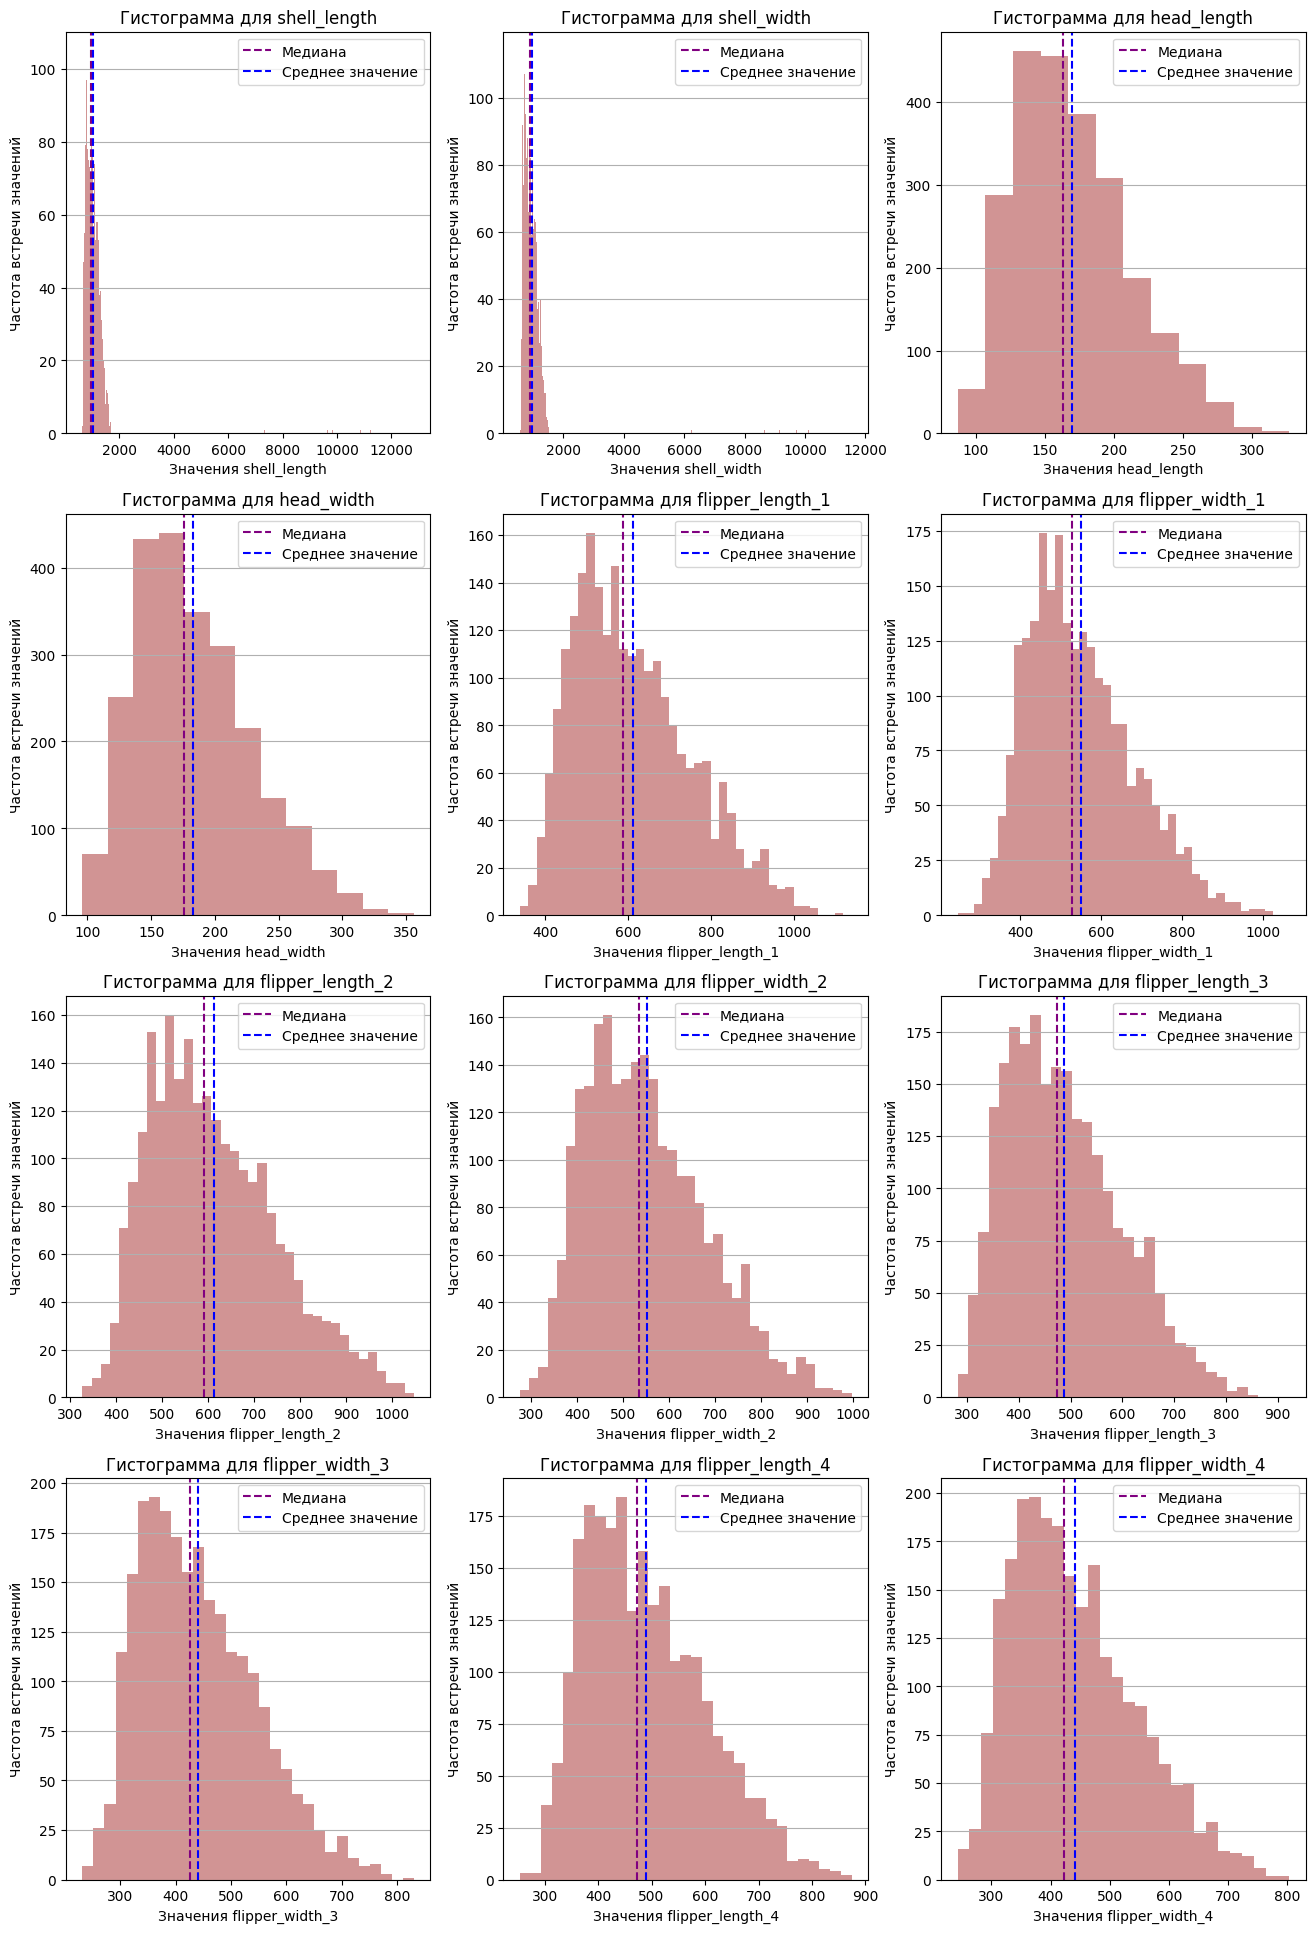

In [34]:
fig, axs = plt.subplots(4, 3, figsize=(16, 24))
for sign in range(count_signs - 1):
    min_value = int(min(df[df.columns[sign]]))
    max_value = int(max(df[df.columns[sign]]))
    median_value = df[df.columns[sign]].median()
    mean_value = df[df.columns[sign]].mean()
    
    axs[sign // 3, sign % 3].hist(df[df.columns[sign]], bins=range(min_value, max_value + 1, 20), color='brown', alpha=0.5)
    axs[sign // 3, sign % 3].set_title(f'Гистограмма для {df.columns[sign]}')
    axs[sign // 3, sign % 3].grid(axis='y')
    axs[sign // 3, sign % 3].set_xlabel(f'Значения {df.columns[sign]}')
    axs[sign // 3, sign % 3].set_ylabel(f'Частота встречи значений')
    axs[sign // 3, sign % 3].axvline(median_value, linewidth=1.5, label='Медиана', color='purple', linestyle='--')
    axs[sign // 3, sign % 3].axvline(mean_value, linewidth=1.5, label='Среднее значение', color='blue', linestyle='--')
    axs[sign // 3, sign % 3].legend()

Построим гистограмму оставшегося, 13-ого признака (он не вошел на предыдущий рисунок).

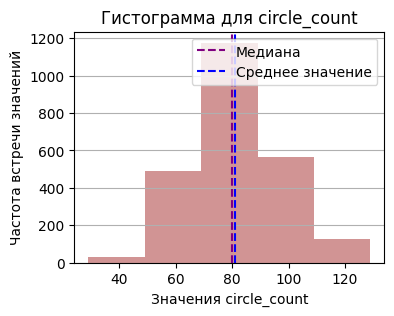

In [35]:
plt.figure(figsize=(4, 3))

# вычисление статистических значений
min_value = int(min(df[df.columns[count_signs - 1]]))
max_value = int(max(df[df.columns[count_signs - 1]]))
median_value = df[df.columns[count_signs - 1]].median()
mean_value = df[df.columns[count_signs - 1]].mean()

plt.hist(df[df.columns[count_signs - 1]], bins=range(min_value, max_value + 1, 20), color='brown', alpha=0.5)
plt.grid(axis='y')

plt.title(f'Гистограмма для {df.columns[count_signs - 1]}')

plt.xlabel(f'Значения {df.columns[count_signs - 1]}')
plt.ylabel(f'Частота встречи значений')

plt.axvline(median_value, linewidth=1.5, label='Медиана', color='purple', linestyle='--')
plt.axvline(mean_value, linewidth=1.5, label='Среднее значение', color='blue', linestyle='--')

plt.legend()
plt.show()

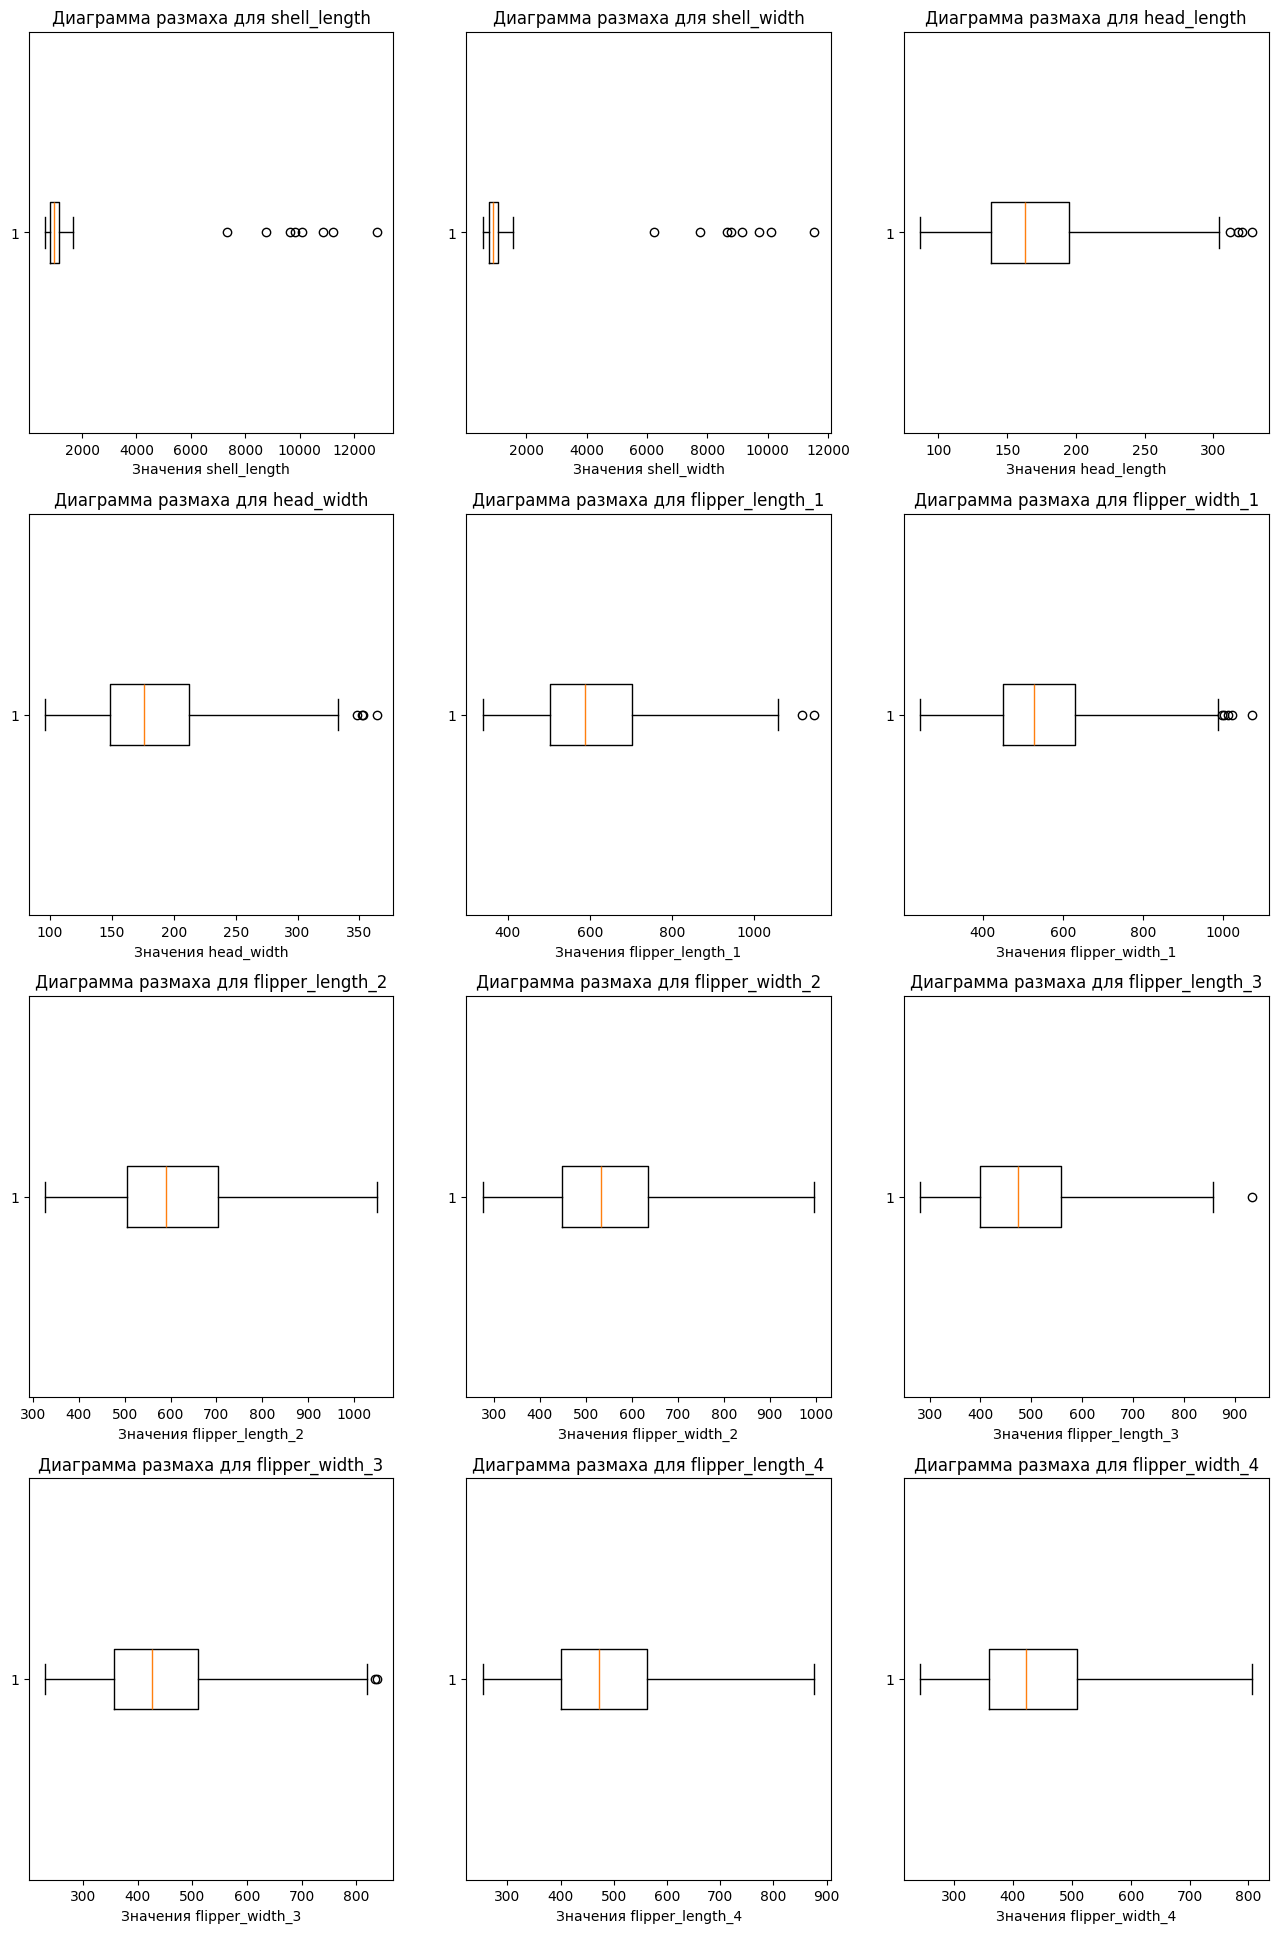

In [36]:
fig, axs = plt.subplots(4, 3, figsize=(16, 24))
for sign in range(count_signs - 1):
    axs[sign // 3 , sign % 3 ].boxplot(df[df.columns[sign]], vert=False, whis=2)
    axs[sign // 3 , sign % 3 ].set_title(f'Диаграмма размаха для {df.columns[sign]}')
    axs[sign // 3 , sign % 3 ].set_xlabel(f'Значения {df.columns[sign]}')

Построим диаграмму размаха оставшегося, 13-ого признака (он не вошел на предыдущий рисунок).

Text(0.5, 0, 'Значения circle_count')

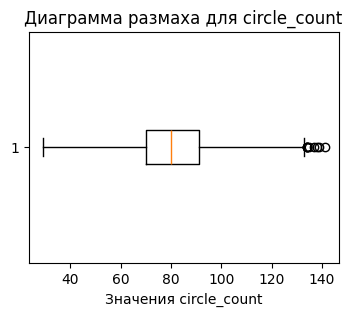

In [37]:
plt.figure(figsize=(4, 3))
plt.boxplot(df[df.columns[count_signs - 1]], vert=False, whis=2)
plt.title(f'Диаграмма размаха для {df.columns[count_signs - 1]}')
plt.xlabel(f'Значения {df.columns[count_signs - 1]}')

Проанализировав гистограммы и диаграммы размаха можно сделать следующие выводы:
- для всех признаков, кроме `shell_length`, `shell_width` распределение на гистограммах является слабо правоассиметричным (имеется небольшой хвост справа). Среднее значение расположено немного правее медианы, что характерно для правого ассиметричного распределения.
- на гистограммах признаков `shell_length`, `shell_width` видно сильное правоассиметричное распределение, причем значения, расположенные в правой части, встречаются очень редко - их трудно разглядеть на графике. Вероятно, это те самые значения, умноженные на 10.
- по диаграммам размаха наблюдается та же тенденция: видно небольшое количество аномалий на графиках признаков `shell_length`, `shell_width`;
- на диаграммах размаха всех признаков, кроме `head_length` и `head_width`, видно небольшое количество значений, выходящих за пределы правого уса, однако они вряд ли являются аномалиями либо выбросами, так как судя по гистограммам они расположены не отдельно, а сочетаются с общей массой данных.

Рассмотрим в увеличенном масштабе в сравнении друг с другом графики диаграммы размаха и гистограммы для признаков `shell_length` и `shell_width`, чтобы принять решение о том, какие данные необходимо будет скорректировать.

Text(0.5, 1.0, 'Диаграмма размаха и гистограмма для признака shell_length')

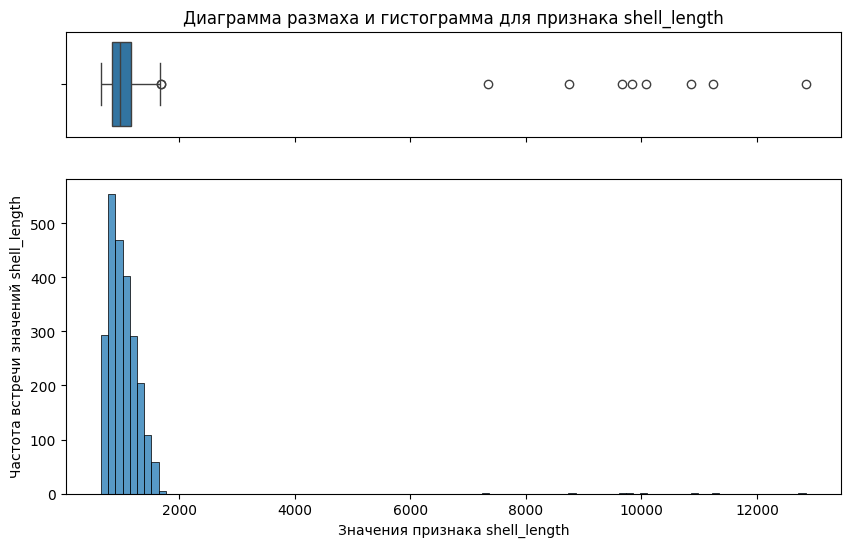

In [38]:
f, (ax_box, ax_hist) = plt.subplots(2, sharex = True, gridspec_kw={"height_ratios": (.25, .75)}, figsize=(10, 6))

sns.boxplot(df["shell_length"], orient="h", ax=ax_box)
sns.histplot(data=df, x="shell_length", ax=ax_hist)

plt.xlabel('Значения признака shell_length')
plt.ylabel('Частота встречи значений shell_length')
ax_box.set_title('Диаграмма размаха и гистограмма для признака shell_length')

Text(0.5, 1.0, 'Диаграмма размаха и гистограмма для признака shell_width')

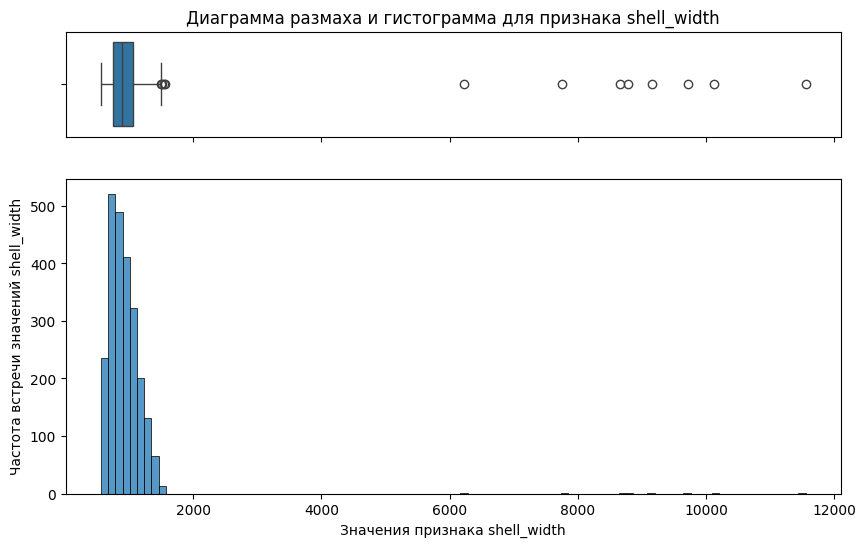

In [39]:
f, (ax_box, ax_hist) = plt.subplots(2, sharex = True, gridspec_kw={"height_ratios": (.25, .75)}, figsize=(10, 6))

sns.boxplot(df["shell_width"], orient="h", ax=ax_box)
sns.histplot(data=df, x="shell_width", ax=ax_hist)

plt.xlabel('Значения признака shell_width')
plt.ylabel('Частота встречи значений shell_width')
ax_box.set_title('Диаграмма размаха и гистограмма для признака shell_width')

Мы видим для признаков `shell_length`, `shell_width` выбросы, начиная со значения примерно 2000. Вероятно, это те самые значения, случайно умноженные на 10, о которых шла речь ранее. Посмотрим, чему равно значение 99,5 перцентиля для них.

In [40]:
print(f'shell_length (99,5 percentile): {df["shell_length"].quantile(0.995)}')
print(f'shell_width (99,5 percentile): {df["shell_width"].quantile(0.995)}')

shell_length (99,5 percentile): 1635.575000000002
shell_width (99,5 percentile): 1499.2000000000007


Значения 99,5 перцентиля находятся около 1700 и 1500 для `shell_length` и `shell_width` соответственно. Проведем деление значений этих столбцов на 10, если их значения превышают 2000.

In [41]:
start_shape = df.shape[0]

Напишем функцию для уменьшения значений столбцов `shell_length`, `shell_width` в 10 раз, если их значения больше 2000.

In [42]:
def del_10(row, column):
    if row[column] > 2000:
        return row[column] / 10
    return row[column]

Уменьшим значения признаков, случайно умноженные на 10.

In [43]:
df['shell_length'] = df.apply(del_10, column='shell_length', axis=1)
df['shell_width'] = df.apply(del_10, column='shell_width', axis=1)

### 4.7 Проверка масштабов признаков.

Проверим масштаб признаков.

In [44]:
df.describe().loc[['min', 'max']].iloc[:, :-1]

,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count
min,645.0,564.0,87.0,96.0,339.0,245.0,327.0,276.0,282.0,231.0,254.0,243.0,29.0
max,1683.0,1554.0,328.0,364.0,1147.0,1072.0,1049.0,997.0,934.0,837.0,877.0,806.0,141.0


В целом масштаб признаков отличается не сильно: у большинства полей значения находятся в пределах от 250 до 1100-1600. Однако, например, у признаков `head_length`, `head_width` значения находятся в пределах от 90 до 370, у `circle_count` - от 30 до 140.

Масштаб признаков может остаться без изменений, так как не имеет глобальных различий, где один признак, например, измерялся бы в десятках, а другой в миллионах единиц. Однако для улучшения предсказаний модели масштабирование может быть применено. В качестве решения проблемы можно использовать как стандартизацию, так и нормализацию мин-макс. 

Мин-макс. Причины за:
- в данных нет выбросов, из-за которых основные значения диапазона могли бы быть сильно сужены;
- будут сохранены относительные различия между минимальнымм и максимальным значениями.

Причина против:
- распределение данных признаков не равномерное.

Стандартизация. Причины за:
- распределение всех признаков датафрейма близко к равномерному;
- не искажает структуру данных, что хорошо подойдет для градиентных методов обучения.

### 4.8 Анализ корреляции между признаками и целевой переменной.

С помощью вычислений проанализируем корреляцию между признаками и целевой переменной.

In [45]:
correlation_matrix = df.phik_matrix()
correlation = pd.DataFrame(correlation_matrix['weight']).sort_values(by='weight')[:-1]

correlation

interval columns not set, guessing: ['shell_length', 'shell_width', 'head_length', 'head_width', 'flipper_length_1', 'flipper_width_1', 'flipper_length_2', 'flipper_width_2', 'flipper_length_3', 'flipper_width_3', 'flipper_length_4', 'flipper_width_4', 'circle_count', 'weight']


,weight
circle_count,0.388131
head_width,0.697746
head_length,0.709728
flipper_width_1,0.735899
flipper_width_3,0.740665
flipper_width_4,0.745202
flipper_width_2,0.747448
flipper_length_2,0.762235
flipper_length_3,0.763505
flipper_length_4,0.763810


Text(0.5, 36.72222222222221, 'Масса черепахи')

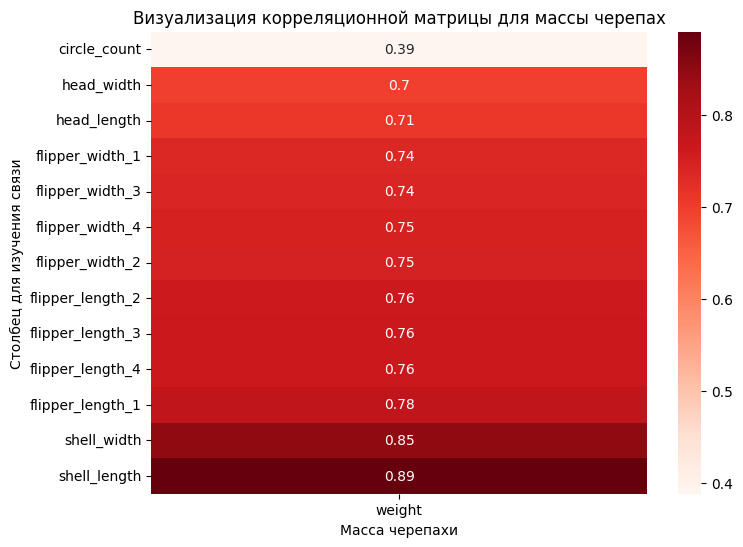

In [46]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, cmap='Reds', annot=True)
plt.title('Визуализация корреляционной матрицы для массы черепах')
plt.ylabel('Столбец для изучения связи')
plt.xlabel('Масса черепахи')

По схеме видно, что масса черепахи (целевая переменная) имеет довольно сильную корреляцию почти со всеми признаками, оставшимися в датафрейме, кроме признака `circle_count` с количеством колец роста на панцире черепахи. Остальные коэффициенты корреляции - от 0.7 для `head_width` до 0.89 для `shell_length`.

Однако в условии было сказано, что кольца роста черепахи (`circle_count`) коррелируют с возрастом, а возраст с размерами и массой. То есть, иными словами, кольца роста коррелируют с размерами и массой. Однако матица корреляции не показала эту связь.

Проверим корреляции с помощью графиков (обозначение "ЦП" - целевая переменная). 

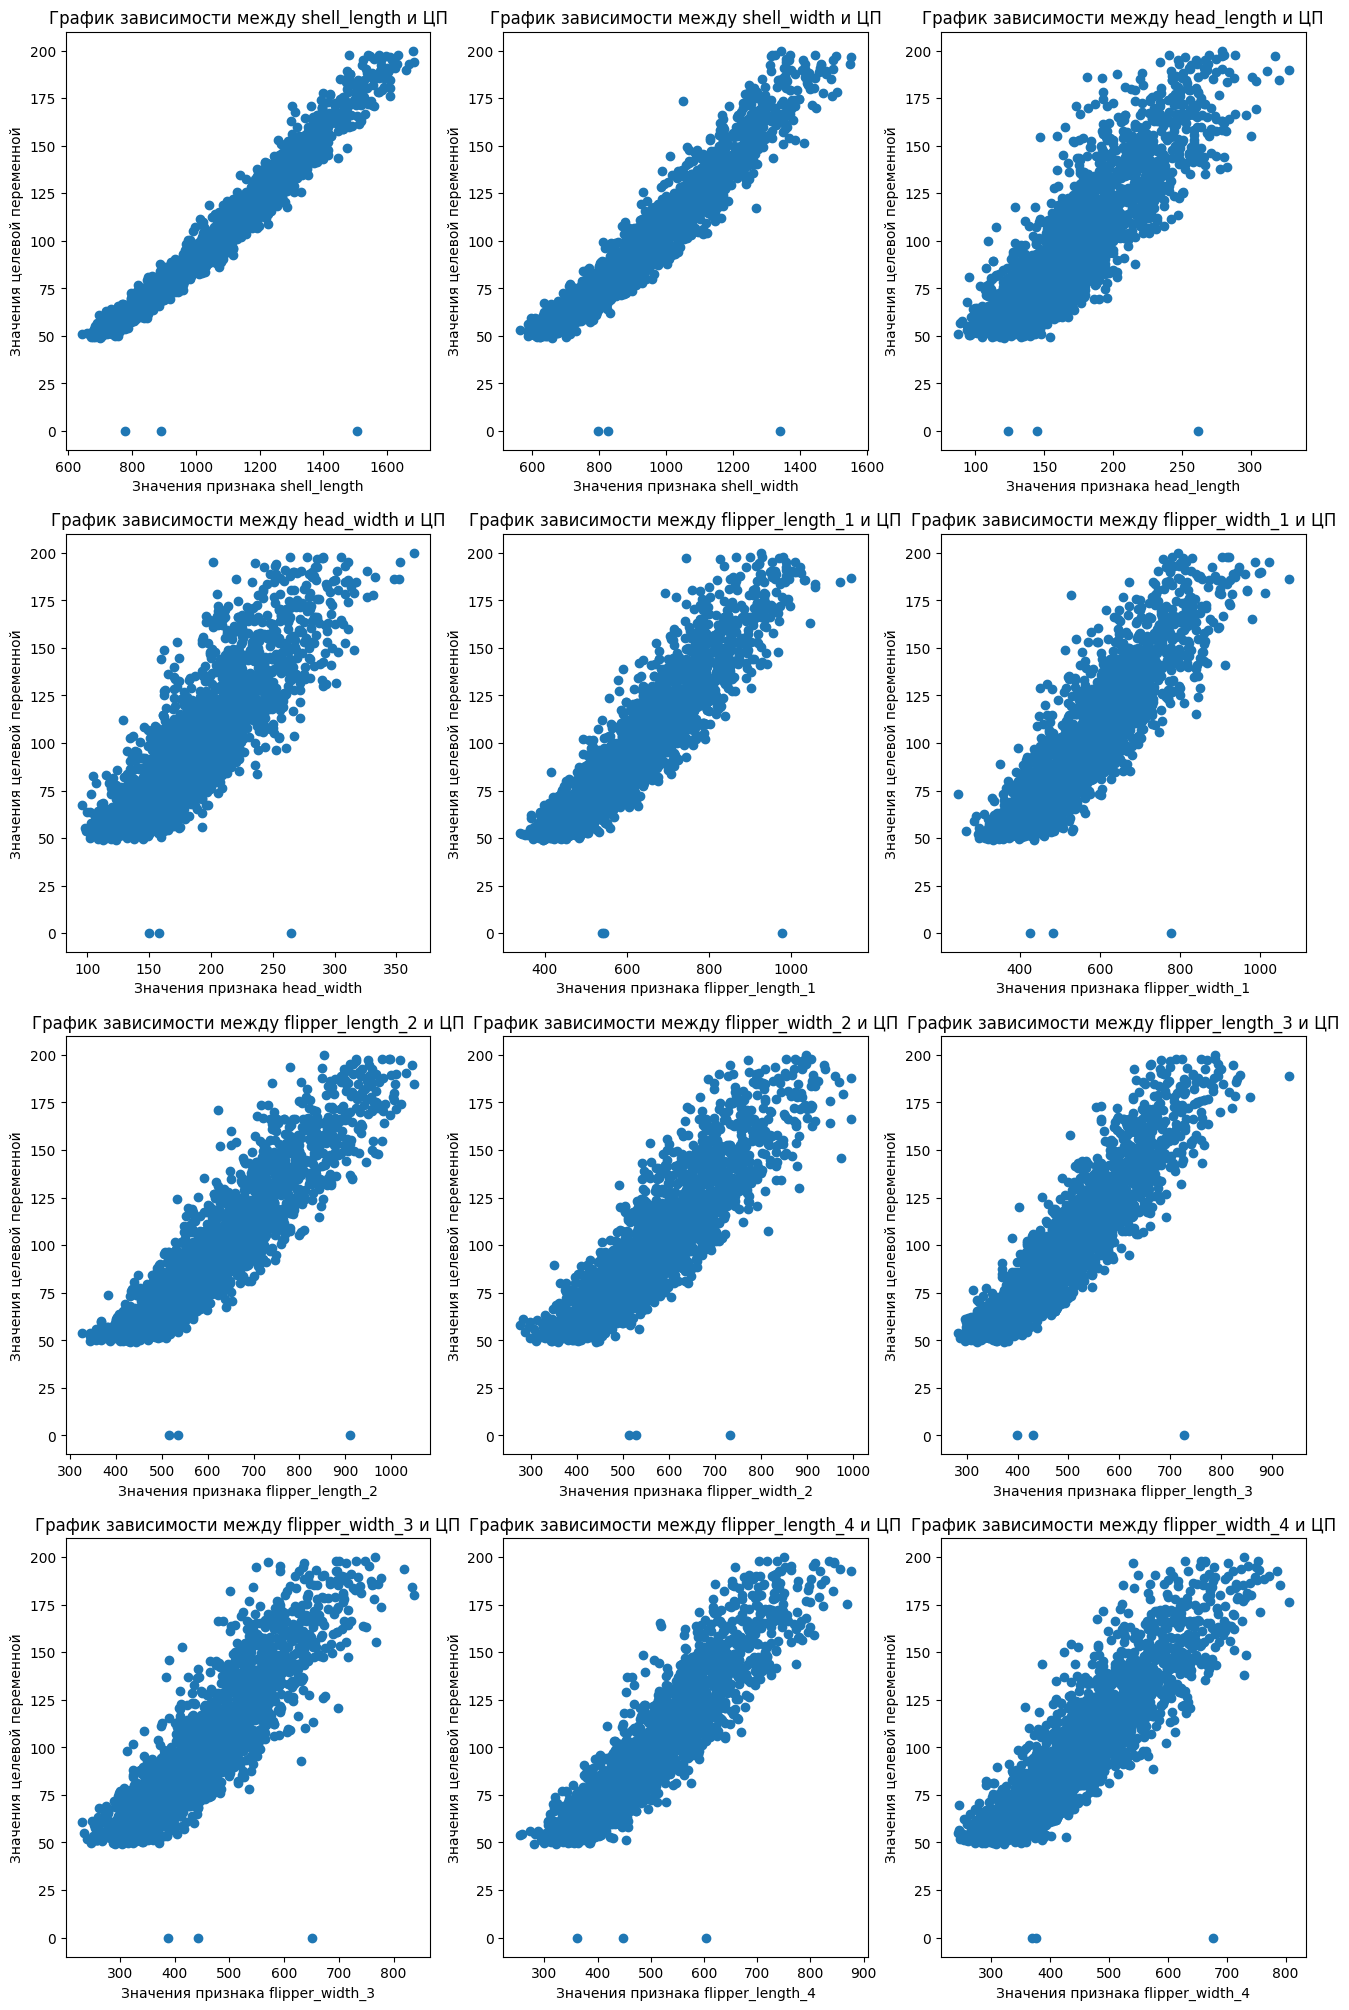

In [47]:
fig, axs = plt.subplots(4, 3, figsize=(16, 25))
for sign in range(count_signs - 1):    
    axs[sign // 3, sign % 3].scatter(x = df[df.columns[sign]], y = df['weight'])
    axs[sign // 3, sign % 3].set_title(f'График зависимости между {df.columns[sign]} и ЦП')
    axs[sign // 3, sign % 3].set_xlabel(f'Значения признака {df.columns[sign]}')
    axs[sign // 3, sign % 3].set_ylabel(f'Значения целевой переменной')

Построим график для оставшегося признака.

Text(0, 0.5, 'Значения целевой переменной')

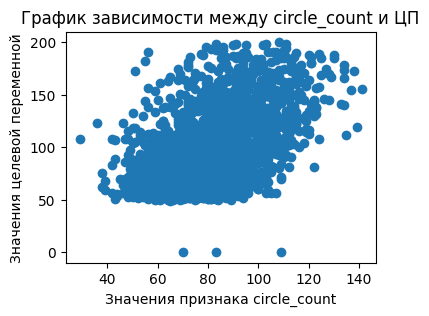

In [48]:
plt.figure(figsize=(4, 3))
plt.scatter(x=df[df.columns[count_signs - 1]], y=df['weight'])
plt.title(f'График зависимости между {df.columns[count_signs - 1]} и ЦП')
plt.xlabel(f'Значения признака {df.columns[count_signs - 1]}')
plt.ylabel(f'Значения целевой переменной')

Графики зависимостей подтвердили довольно сильную зависимость (в данному случае линейную) между признаками датасета (кроме `circle_count`) и целевой переменной. 

Для признака `circle_count`: не прослеживается какой-либо четкой зависимости, интересующей нас (в том числе линейной). 

Можно постараться проследить довольно слабую линейную зависимость, но даже в таком случае большинство точек будут далеко от прямой, которую мы постараемся провести через точки данного графика.

Некоторые признаки уже были удалены ранее. Из оставшихся признаков, с учетом того, что в условии было сказано о зависимости целевой переменной от `circle_count`, стоит оставить все.

### 4.9 Проверка на мультиколлинеарность.

Вновь посмотрим на матрицу корреляций, но уже для всех признаков, чтобы определить случаи мультиколлинеарности.

In [49]:
correlation = df.iloc[:, :-1].phik_matrix()
correlation

interval columns not set, guessing: ['shell_length', 'shell_width', 'head_length', 'head_width', 'flipper_length_1', 'flipper_width_1', 'flipper_length_2', 'flipper_width_2', 'flipper_length_3', 'flipper_width_3', 'flipper_length_4', 'flipper_width_4', 'circle_count']


,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count
shell_length,1.000000,0.925508,0.822421,0.817944,0.881723,0.848290,0.871619,0.853211,0.874565,0.851130,0.876948,0.854517,0.515163
shell_width,0.925508,1.000000,0.807577,0.791989,0.858902,0.835538,0.858371,0.839506,0.859849,0.829047,0.853143,0.842189,0.502604
head_length,0.822421,0.807577,1.000000,0.721945,0.775409,0.762339,0.773973,0.761660,0.783544,0.753941,0.766286,0.756374,0.466484
head_width,0.817944,0.791989,0.721945,1.000000,0.764305,0.734162,0.764519,0.754477,0.769413,0.757741,0.780811,0.749206,0.451613
flipper_length_1,0.881723,0.858902,0.775409,0.764305,1.000000,0.799661,0.819923,0.808984,0.813201,0.814656,0.811316,0.796308,0.483010
flipper_width_1,0.848290,0.835538,0.762339,0.734162,0.799661,1.000000,0.788804,0.791968,0.797501,0.789565,0.790262,0.784006,0.477170
flipper_length_2,0.871619,0.858371,0.773973,0.764519,0.819923,0.788804,1.000000,0.796265,0.812127,0.791348,0.808325,0.799929,0.485122
flipper_width_2,0.853211,0.839506,0.761660,0.754477,0.808984,0.791968,0.796265,1.000000,0.804382,0.784267,0.813681,0.774867,0.468056
flipper_length_3,0.874565,0.859849,0.783544,0.769413,0.813201,0.797501,0.812127,0.804382,1.000000,0.793260,0.817346,0.796900,0.489532
flipper_width_3,0.851130,0.829047,0.753941,0.757741,0.814656,0.789565,0.791348,0.784267,0.793260,1.000000,0.795089,0.788912,0.470852


Text(0.5, 1.0, 'Матрица корреляций для всех признаков')

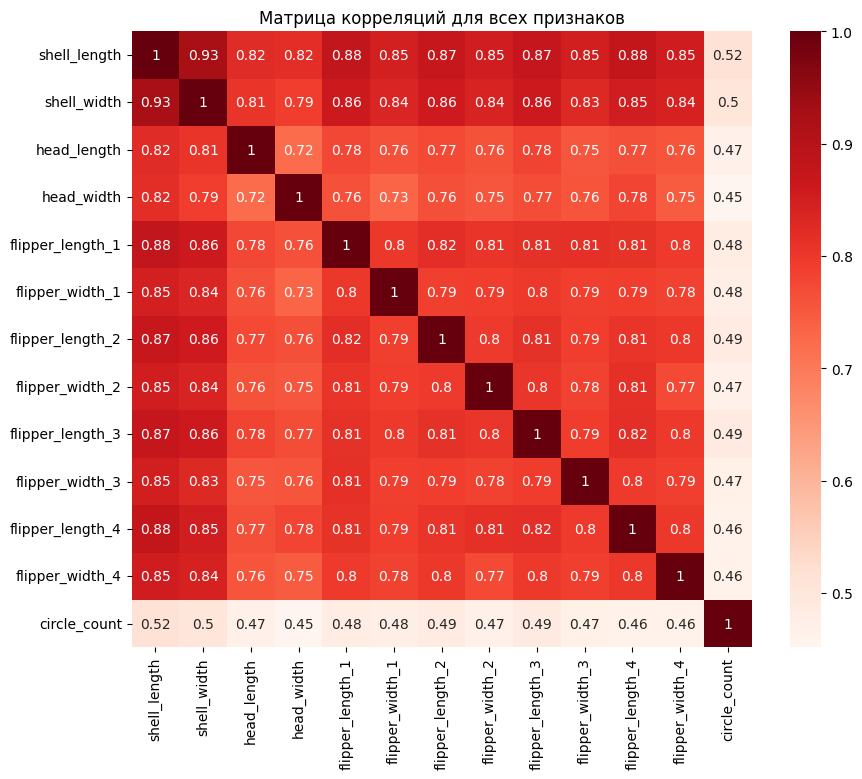

In [50]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, cmap='Reds', annot=True)
plt.title('Матрица корреляций для всех признаков')

В данных видны признаки сильное мультиколлинеарности. В целом многие признаки коррелируют друг с другом. Например, у признака `shell_length` корреляция больше 0.8 со всеми признаками, кроме `circle_count`.

Можно ослабить влияние мультиколлинеарности, использовав регуляризацию (Lasso или Ridge). Lasso (L1) регуляризация позволит отобрать некоторые признаки и обнулить веса при других, Ridge (L2) регуляризация позволит уравновесить коэффициенты при каждом признаке. Регуляризации позволят чуть больше уравновесить проблему с мультиколлинеарностью, при которой модель будет нестабильна из-за присваивания каждый раз разных весов сильно коррелирующим признакам. 

## Предобработка данных

### 5.1 Разделение данных на выборки.

Разделим данные на выборки: обучающую (60%), валидационную (20%) и тестовую (20%). 

In [51]:
X = df.drop(columns=['weight'])
y = df['weight']
X.head()

,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count
8,742.0,652.0,118.0,147.0,411,386,507,389,414.0,368.0,311.0,325.0,66
11,1336.0,1318.0,207.0,248.0,845,704,661,768,587.0,686.0,661.0,585.0,111
16,1010.0,926.0,216.0,156.0,562,488,529,432,467.0,434.0,553.0,463.0,76
21,982.0,940.0,187.0,157.0,518,557,545,463,497.0,511.0,541.0,479.0,103
23,887.0,813.0,149.0,140.0,578,514,538,472,462.0,308.0,408.0,396.0,70


In [52]:
y.head()

8      56.352
11    154.074
16     87.695
21     92.707
23     75.829
Name: weight, dtype: float64

In [53]:
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, shuffle=True, random_state=42)
print(f'''X_train: {X_train.shape}, y_train: {y_train.shape};
X_val: {X_val.shape}, y_val: {y_val.shape};
X_test: {X_test.shape}, y_test: {y_test.shape};
''')

X_train: (1437, 13), y_train: (1437,);
X_val: (479, 13), y_val: (479,);
X_test: (480, 13), y_test: (480,);



Данные были разделены на 3 выборки.

### 5.2 Работа с пропусками.

Пропуски были обработаны в пункте 4. Убедимся, что пропусков не осталось.

In [54]:
df.isna().sum()

shell_length        0
shell_width         0
head_length         0
head_width          0
flipper_length_1    0
flipper_width_1     0
flipper_length_2    0
flipper_width_2     0
flipper_length_3    0
flipper_width_3     0
flipper_length_4    0
flipper_width_4     0
circle_count        0
weight              0
dtype: int64

Выборки были сделаны из датафрейма `df`, в нем пропусков нет, а значит и в выборках тоже.

### 5.3 Написание функции для стандартизации признаков

Напишем функцию для масштабирования признаков с помощью стандартизации.

In [55]:
def standard(X_train, X_val, X_test):
    mean_val = X_train.mean()
    std_val = X_train.std()

    X_train_scaled = (X_train - mean_val) / std_val
    X_val_scaled = (X_val - mean_val) / std_val
    X_test_scaled = (X_test - mean_val) / std_val

    return X_train_scaled, X_val_scaled, X_test_scaled

### 5.4 Написание функции для нормализации признаков (мин-макс)

Напишем функцию для масштабирования признаков с помощью нормализации мин-макс.

In [56]:
def minmax(X_train, X_val, X_test):
    min_val = X_train.min()
    max_val = X_train.max()

    X_train_scaled = (X_train - min_val) / (max_val - min_val)
    X_val_scaled = (X_val - min_val) / (max_val - min_val)
    X_test_scaled = (X_test - min_val) / (max_val - min_val)

    return X_train_scaled, X_val_scaled, X_test_scaled

### 5.5 Подготовка датасетов

Датасеты без масштабирования были получены ранее.  

Получим датасеты с нормализацией.

In [57]:
X_train_minmax, X_val_minmax, X_test_minmax = minmax(X_train, X_val, X_test)

Получим датасеты со стандартизацией.

In [58]:
X_train_standard, X_val_standard, X_test_standard = standard(X_train, X_val, X_test)

## Обучение моделей

### 6.1 Построение базовой модели (дамми)

Перед началом построения базовой модели так же напишем несколько функций и создадим словарь.

Напишем функцию для расчета метрик.

In [59]:
def calculate_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    
    return {'MAE': round(mae, 2),
            'MSE': round(mse, 2),
            'MAPE': round(mape * 100, 3),
            'R2': round(r2, 2)}

Создадим словарь, куда будем сохранять метрики моделей.

In [60]:
# 0 - mae, 1 - mse, 2 - mape, 3 - r2
dict_metrics = {0: [], 1: [], 2: [], 3: []}

Создадим функцию для заполнения словаря метриками.

In [61]:
def add_metric(metrics):
    sp_metrics = list(metrics.values())
    for metric in range(len(sp_metrics)):
        dict_metrics[metric].append(sp_metrics[metric])

Создадим функцию для подробного вывода метрик каждой модели.

In [62]:
def print_metric(model_name, metrics_train, metrics_val):
    print(f'Метрики для {model_name}:\n')
    print(f'''Метрики на train без масштабирования, модель: {model_name}.
{metrics_train}\n
Метрики на val без масштабирования, модель: {model_name}.
{metrics_val}''')

---

Построим базовую модель, которая всегда будет предсказывать среднее значение целевой переменной из обучающей выборки.

In [63]:
dummy = DummyRegressor(strategy='mean')

Обучим модель.

In [64]:
dummy.fit(X_train, y_train)

,"strategy strategy: {""mean"", ""median"", ""quantile"", ""constant""}, default=""mean""Strategy to use to generate predictions.* ""mean"": always predicts the mean of the training set* ""median"": always predicts the median of the training set* ""quantile"": always predicts a specified quantile of the training set, provided with the quantile parameter.* ""constant"": always predicts a constant value that is provided by the user.",'mean'
,"constant constant: int or float or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
,"quantile quantile: float in [0.0, 1.0], default=NoneThe quantile to predict using the ""quantile"" strategy. A quantile of0.5 corresponds to the median, while 0.0 to the minimum and 1.0 to themaximum.",None


Получим предсказания, использовав немасштабированную выборку.

In [65]:
dummy_train_predict = dummy.predict(X_train)
dummy_val_predict = dummy.predict(X_val)

Добавим метрики в словарь для итоговой таблицы и выведем метрики

In [66]:
add_metric(calculate_metrics(y_val, dummy_val_predict))

print_metric('Dummy', 
             calculate_metrics(y_train, dummy_train_predict), 
             calculate_metrics(y_val, dummy_val_predict))

Метрики для Dummy:

Метрики на train без масштабирования, модель: Dummy.
{'MAE': 28.56, 'MSE': 1220.64, 'MAPE': 6.066055615107142e+16, 'R2': 0.0}

Метрики на val без масштабирования, модель: Dummy.
{'MAE': 27.94, 'MSE': 1134.27, 'MAPE': 32.829, 'R2': -0.01}


### 6.2 Построение и обучение разных архитектур

Наметим план использования моделей:
- модель: LinearRegression. Признаки: немасштабированные. Обоснование: так как LinearRegression решает поставленную задачу аналитическим способом, масштаб признаков не повлияет на ее работу;
- модель: Lasso. Признаки: масштабированные с помощью стандартизации. Обоснование: Lasso штрафует модель за слишком большие веса и может обнулять некоторые признаки. В случае с мин-макс есть вероятность, что из-за чрезмерного скопления значений в одной части, признаку назначится некорректный вес (слишком большой), а Lasso в свою очередь некорректно его оштрафует;
- модель: Lasso. Признаки: масштабированные с помощью мин-макс. Обоснование: для сравнения с предыдущим вариантом;
- модель: Ridge. Признаки: масштабированные с помощью стандартизации. Обоснование: как и у Lasso с такими же признаками;
- модель: SGDRegressor. Признаки: масштабированные с помощью стандартизации. Обоснование: мин-макс стандартизация сочетается не так хорошо с градиентными методами. Loss: MSE;
- модель: SGDRegressor. Признаки: масштабированные с помощью стандартизации. Обоснование: мин-макс стандартизация сочетается не так хорошо с градиентными методами. Loss: epsilon_insensitive.
  
Для моделей типа SGDRegressor попробуем разные скорости обучения.

#### Работа с моделью LinearRegression

Реализуем первый тип модели - LinearRegression. Создание и обучение модели.

In [67]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Совершение предсказаний моделью.

In [68]:
lr_predict_train = lr.predict(X_train)
lr_predict_val = lr.predict(X_val)

In [69]:
add_metric(calculate_metrics(y_val, lr_predict_val))

print_metric('LinearRegression', 
             calculate_metrics(y_train, lr_predict_train), 
             calculate_metrics(y_val, lr_predict_val))

Метрики для LinearRegression:

Метрики на train без масштабирования, модель: LinearRegression.
{'MAE': 3.75, 'MSE': 44.2, 'MAPE': 7.389995335300952e+16, 'R2': 0.96}

Метрики на val без масштабирования, модель: LinearRegression.
{'MAE': 3.6, 'MSE': 21.46, 'MAPE': 4.04, 'R2': 0.98}


Метрики модели типа LinearRegression на валидационной выборке показали хороший результат:
- MAE = 3.75;
- MSE = 21.46;
- MAPE = 4%;
- R^2 = 98%.

Метрика MAE сообщает о том, что средняя абсолютная ошибка равна всего 3.75 кг, что уже соответствует требованиям бизнес-задачи (по требованию MAE менее 5 кг), средняя квадратичная ошибка MSE составляет около 22 единиц, ее значение большое по сравнению с MAE, так как она измеряется в квадратах единиц целевой переменной. С учетом этого, если посчитать RMSE - корень из MSE, который уже измеряется в единицах целевой переменной (кг), получим так же довольно низкий результат в 4.6 единиц:

In [70]:
round(np.sqrt(dict_metrics[1][-1]), 2)

np.float64(4.63)

Процентная ошибка модели составляет всего 4%, модель имеет хорошую способность объяснять данные - она объясняет 98% данных. Значение в 98% так же удовлетворяет требованиям бизнес-задачи, где метрика R^2 должна быть не менее 97%.

#### Работа с моделью Lasso (стандартизация признаков)

Реализуем модель Lasso с использованием масштабированных с помощью стандартизации признаков.

Создание и обучение модели.

In [71]:
lasso_st = Lasso()
lasso_st.fit(X_train_standard, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


Предсказания для Lasso, standard.

In [72]:
lasso_st_predict_train = lasso_st.predict(X_train_standard)
lasso_st_predict_val = lasso_st.predict(X_val_standard)

In [73]:
add_metric(calculate_metrics(y_val, lasso_st_predict_val))

print_metric('Lasso (standard)', 
             calculate_metrics(y_train, lasso_st_predict_train), 
             calculate_metrics(y_val, lasso_st_predict_val))

Метрики для Lasso (standard):

Метрики на train без масштабирования, модель: Lasso (standard).
{'MAE': 3.77, 'MSE': 45.55, 'MAPE': 7.336685481762574e+16, 'R2': 0.96}

Метрики на val без масштабирования, модель: Lasso (standard).
{'MAE': 3.58, 'MSE': 23.0, 'MAPE': 3.849, 'R2': 0.98}


Метрики модели типа Lasso (использующей регуляризацию) с использованием стандартизации признаков на валидационной выборке показали так же хороший результат:
- MAE = 3.58;
- MSE = 23;
- MAPE = 3.85%;
- R^2 = 98%.

Метрика MAE сообщает о том, что средняя абсолютная ошибка равна всего 3.58 кг, что так же соответствует требованиям бизнес-задачи (по требованию MAE менее 5 кг). Значение метрики снизилось по сравнению с LinearRegression. Средняя квадратичная ошибка MSE составляет около 23 единиц. Если говорить об ошибке модели в процентах, то процентная ошибка модели составляет всего 3.85% - метрика так же снизилась по сравнению с LinearRegression. Модель умеет объяснять 98% данных, что удовлетворяет требованиям бизнес-задачи (где R^2 должнен быть не менее 97%).

#### Работа с моделью Lasso (мин-макс)

Создание и обучение модели.

In [74]:
lasso_minmax = Lasso()
lasso_minmax.fit(X_train_minmax, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


Предсказания для Lasso, minmax.

In [75]:
lasso_minmax_predict_train = lasso_minmax.predict(X_train_minmax)
lasso_minmax_predict_val = lasso_minmax.predict(X_val_minmax)

In [76]:
add_metric(calculate_metrics(y_val, lasso_minmax_predict_val))

print_metric('Lasso (min-max)', 
             calculate_metrics(y_train, lasso_minmax_predict_train), 
             calculate_metrics(y_val, lasso_minmax_predict_val))

Метрики для Lasso (min-max):

Метрики на train без масштабирования, модель: Lasso (min-max).
{'MAE': 5.74, 'MSE': 77.08, 'MAPE': 7.116099687336924e+16, 'R2': 0.94}

Метрики на val без масштабирования, модель: Lasso (min-max).
{'MAE': 5.33, 'MSE': 53.62, 'MAPE': 5.553, 'R2': 0.95}


Можно заметить, что судя по основным метрикам задачи (R^2, MAE) Lasso со standard действительно справился лучше, чем Lasso с min-max.

Метрики модели типа Lasso (использующей регуляризацию) с использованием масштабирования мин-макс на валидационной выборке показали недостаточный результат:
- MAE = 5.33;
- MSE = 53.62;
- MAPE = 5.55%;
- R^2 = 95%.

Метрика MAE сообщает о том, что средняя абсолютная ошибка равна 5.33 кг, данное значение не является допустимым по требованиям бизнес-задачи (по требованию - MAE должна быть не более 5 кг). 

Средняя квадратичная ошибка MSE увеличилась по сравнению с метриками других моделей примерно в 2 раза и составляет около 54 единиц. Если говорить об ошибке модели в процентах (MAPE), то она претерпела меньшие изменения - составляет 5.55%. MAPE высчитывает метрику, не обращая внимания на масштабы данных. Тогда несильное изменение MAPE и довольно сильное изменение MSE, сильно реагирующей на большие значения, может говорить о том, что модель начала хуже справляться из-за более больших значений выборки. 

Кроме того модель умеет объяснять 95% данных, что явлется довольно высоким значением, но не удовлетворяет требованиям бизнес-задачи в минимум 97%.

#### Работа с моделью Ridge (стандартизация признаков)

Создание и обучение модели.

In [77]:
ridge = Ridge()
ridge.fit(X_train_standard, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


Предсказания для Lasso, minmax.

In [78]:
ridge_predict_train = ridge.predict(X_train_standard)
ridge_predict_val = ridge.predict(X_val_standard)

In [79]:
add_metric(calculate_metrics(y_val, ridge_predict_val))

print_metric('Ridge', 
             calculate_metrics(y_train, ridge_predict_train), 
             calculate_metrics(y_val, ridge_predict_val))

Метрики для Ridge:

Метрики на train без масштабирования, модель: Ridge.
{'MAE': 3.75, 'MSE': 44.2, 'MAPE': 7.391319272436192e+16, 'R2': 0.96}

Метрики на val без масштабирования, модель: Ridge.
{'MAE': 3.6, 'MSE': 21.46, 'MAPE': 4.037, 'R2': 0.98}


Метрики модели типа Ridge (использующей регуляризацию) с использованием стандартизации признаков на валидационной выборке показали хороший результат:
- MAE = 3.6;
- MSE = 21.46;
- MAPE = 4.037%;
- R^2 = 98%.

Средняя абсолютная ошибка (MAE) равна всего 3.6 кг, что соответствует требованиям бизнес-задачи (по требованию MAE менее 5 кг). Средняя квадратичная ошибка MSE составляет около 21.5 единиц. Процентная ошибка модели составляет 4.037%. Модель умеет объяснять 98% данных, что удовлетворяет требованиям бизнес-задачи (где R^2 должнен быть не менее 97%).

#### Работа с моделью SGDRegressor (стандартизация признаков, MSE, низкая скорость)

Перемешаем данные, поставим постоянную скорость изменения = 0.001.

In [80]:
sgd_mse_low_speed = SGDRegressor(loss='squared_error', random_state=42, shuffle=True, learning_rate='constant', eta0=0.001)

In [81]:
sgd_mse_low_speed.fit(X_train_standard, y_train)

,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide `.",'squared_error'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [82]:
sgd_mse_low_speed_predict_train = sgd_mse_low_speed.predict(X_train_standard)
sgd_mse_low_speed_predict_val = sgd_mse_low_speed.predict(X_val_standard)

In [83]:
add_metric(calculate_metrics(y_val, sgd_mse_low_speed_predict_val))

print_metric('SGDRegressor (низкая скорость, стандартизация признаков, MSE)', 
             calculate_metrics(y_train, sgd_mse_low_speed_predict_train), 
             calculate_metrics(y_val, sgd_mse_low_speed_predict_val))

Метрики для SGDRegressor (низкая скорость, стандартизация признаков, MSE):

Метрики на train без масштабирования, модель: SGDRegressor (низкая скорость, стандартизация признаков, MSE).
{'MAE': 3.77, 'MSE': 44.49, 'MAPE': 7.410905021225987e+16, 'R2': 0.96}

Метрики на val без масштабирования, модель: SGDRegressor (низкая скорость, стандартизация признаков, MSE).
{'MAE': 3.61, 'MSE': 21.59, 'MAPE': 4.016, 'R2': 0.98}


Метрики модели типа SGDRegressor (использующей стохастический градиентный спуск) с использованием лосса `squared_error` равны следующим значениям:
- MAE = 3.61;
- MSE = 21.59;
- MAPE = 4.016%;
- R^2 = 98%.

Средняя абсолютная ошибка (MAE) равна 3.61 кг, что соответствует требованиям бизнес-задачи (по требованию MAE менее 5 кг). Средняя квадратичная ошибка MSE составляет около 21.6 единиц. Процентная ошибка модели составляет 4.016%. Модель умеет объяснять 98% данных, что удовлетворяет требованиям бизнес-задачи (где R^2 должнен быть не менее 97%).

#### Работа с моделью SGDRegressor (стандартизация признаков, epsilon_insensitive, низкая скорость)

Перемешаем данные, поставим постоянную скорость изменения = 0.001.

In [84]:
sgd_eps_ins_low_speed = SGDRegressor(loss='epsilon_insensitive', random_state=42, shuffle=True, learning_rate='constant', eta0=0.001)

In [85]:
sgd_eps_ins_low_speed.fit(X_train_standard, y_train)

,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide `.",'epsilon_insensitive'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [86]:
sgd_eps_ins_low_speed_predict_train = sgd_eps_ins_low_speed.predict(X_train_standard)
sgd_eps_ins_low_speed_predict_val = sgd_eps_ins_low_speed.predict(X_val_standard)

In [87]:
add_metric(calculate_metrics(y_val, sgd_eps_ins_low_speed_predict_val))

print_metric('SGDRegressor (низкая скорость, стандартизация признаков, epsilon_insensitive)', 
             calculate_metrics(y_train, sgd_eps_ins_low_speed_predict_train), 
             calculate_metrics(y_val, sgd_eps_ins_low_speed_predict_val))

Метрики для SGDRegressor (низкая скорость, стандартизация признаков, epsilon_insensitive):

Метрики на train без масштабирования, модель: SGDRegressor (низкая скорость, стандартизация признаков, epsilon_insensitive).
{'MAE': 3.73, 'MSE': 45.29, 'MAPE': 7.494304526127088e+16, 'R2': 0.96}

Метрики на val без масштабирования, модель: SGDRegressor (низкая скорость, стандартизация признаков, epsilon_insensitive).
{'MAE': 3.59, 'MSE': 22.21, 'MAPE': 3.912, 'R2': 0.98}


Метрики модели типа SGDRegressor (использующей стохастический градиентный спуск) с использованием лосса `epsilon_insensitive` и скорости, равной 0.001, составляет следующие значения:
- MAE = 3.59;
- MSE = 22.21;
- MAPE = 3.912%;
- R^2 = 98%.

Средняя абсолютная ошибка (MAE) равна 3.59 кг, что соответствует требованиям бизнес-задачи (по требованию MAE менее 5 кг). Средняя квадратичная ошибка MSE составляет около 22.21 единиц. Процентная ошибка модели составляет 3.912%. Модель умеет объяснять 98% данных, что удовлетворяет требованиям бизнес-задачи (где R^2 должнен быть не менее 97%).

#### Работа с моделью SGDRegressor (стандартизация признаков, epsilon_insensitive, более высокая скорость)

Перемешаем данные, поставим постоянную скорость изменения = 0.01.

In [88]:
sgd_eps_high_speed = SGDRegressor(loss='epsilon_insensitive', random_state=42, shuffle=True, learning_rate='constant', eta0=0.01)

In [89]:
sgd_eps_high_speed.fit(X_train_standard, y_train)

,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide `.",'epsilon_insensitive'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [90]:
sgd_eps_high_speed_predict_train = sgd_eps_high_speed.predict(X_train_standard)
sgd_eps_high_speed_predict_val = sgd_eps_high_speed.predict(X_val_standard)

In [91]:
add_metric(calculate_metrics(y_val, sgd_eps_high_speed_predict_val))

print_metric('Метрики для SGDRegressor (более высокая скорость, стандартизация признаков, epsilon_insensitive)', 
             calculate_metrics(y_train, sgd_eps_high_speed_predict_train), 
             calculate_metrics(y_val, sgd_eps_high_speed_predict_val))

Метрики для Метрики для SGDRegressor (более высокая скорость, стандартизация признаков, epsilon_insensitive):

Метрики на train без масштабирования, модель: Метрики для SGDRegressor (более высокая скорость, стандартизация признаков, epsilon_insensitive).
{'MAE': 3.69, 'MSE': 44.92, 'MAPE': 7.47341971449106e+16, 'R2': 0.96}

Метрики на val без масштабирования, модель: Метрики для SGDRegressor (более высокая скорость, стандартизация признаков, epsilon_insensitive).
{'MAE': 3.56, 'MSE': 22.05, 'MAPE': 3.884, 'R2': 0.98}


Метрики модели типа SGDRegressor (использующей стохастический градиентный спуск) с использованием лосса `epsilon_insensitive` и скорости, равной 0.01, составляет следующие значения:
- MAE = 3.56;
- MSE = 22.05;
- MAPE = 3.884%;
- R^2 = 98%.

Средняя абсолютная ошибка (MAE) равна 3.56 кг, что соответствует требованиям бизнес-задачи (по требованию MAE менее 5 кг). Средняя квадратичная ошибка MSE составляет около 22.05 единиц. Процентная ошибка модели составляет 3.884%. Модель умеет объяснять 98% данных, что удовлетворяет требованиям бизнес-задачи (где R^2 должнен быть не менее 97%).

### 6.3 Формирование итоговой таблицы с результатами моделей

Сформируем итоговую таблицу с результатами моделей.

In [92]:
models = ['Dummy', 'LinearRegression', 'Lasso', 'Lasso', 'Ridge', 'SGDRegressor (MSE)', 'SGDRegressor (epsilon_insensitive, speed=0.001)', 'SGDRegressor (epsilon_insensitive, speed=0.01)']
scale = ['Без масштабирования', 'Без масштабирования', 'standard', 'min-max', 'standard', 'standard', 'standard', 'standard']

In [93]:
result_models = pd.DataFrame({'Модель': models, 
                              'Название датасета': scale,
                              'MAE': dict_metrics[0],
                              'MSE': dict_metrics[1],
                              'MAPE': dict_metrics[2],
                              'R^2': dict_metrics[3]
                             }).sort_values(by=['MAE', 'R^2', 'MSE', 'MAPE'], ascending=[False, True, False, False])
result_models

,Модель,Название датасета,MAE,MSE,MAPE,R^2
0,Dummy,Без масштабирования,27.94,1134.27,32.829,-0.01
3,Lasso,min-max,5.33,53.62,5.553,0.95
5,SGDRegressor (MSE),standard,3.61,21.59,4.016,0.98
1,LinearRegression,Без масштабирования,3.60,21.46,4.040,0.98
4,Ridge,standard,3.60,21.46,4.037,0.98
6,"SGDRegressor (epsilon_insensitive, speed=0.001)",standard,3.59,22.21,3.912,0.98
2,Lasso,standard,3.58,23.00,3.849,0.98
7,"SGDRegressor (epsilon_insensitive, speed=0.01)",standard,3.56,22.05,3.884,0.98


Итоговая таблица была сформирована. Сделаем выводы о моделях в пункте 7.

## Сравнение моделей на валидационной выборке

### 7.1 Сравнение моделей

В результате создания моделей и выполнения предсказаний на валидационной выборке было выявлено следующее:
- dummy- модель, предсказывающая всегда среднее значение, дала наихудшие результаты - на val метрика MAE близка к 29, хотя должна быть в пределах 5, коэффициент детерминации так же очень низкий - модель объясняет 0% данных. Это легко объясняется "наивностью" модели и отсуствием каких-либо серьезных логических вычислений;
- Lasso модель с min-max масштабирование так же показала не очень хорошие результаты - метрика MAE превосходит заданный диапазон и составляет 5.22, MSE так же показывает не очень хороший результат в 49 единиц. При этом отклонение от прогнозов и коэффициент детерминации имеют довольно хорошие значения - около 5.5% и 96% соот-но. Вероятно, были получены не столь хорошие результаты из-за того, что для некоторых признаков произошло скопление значений в одном месте, из-за которых lasso некорректно оштрафовало веса;
- модели SGDRegressor (MSE) и SGDRegressor (epsilon_insensitive, speed=0.001) со standard-масштабированием, а также Ridge и LinearRegression показали примерно одинаковые достаточно хорошие результаты. Основная метрика MAE у всех этих моделей укладывается в 5 единиц (в диапазоне от 3.45 до 3.5), MSE так же не большое (19.22-20.27), очень похожий процент MAPE около 3.8, они объясняют 98% данных. Можно увидеть, что для данных хорошо подошла стандартизация в качестве способа масштабирования. Стоит отметить, что по сравнению с более сложными моделями со стохастическим градиентным спуском и Ridge-регуляризацией, базовое аналитическое решение LinearRegression справилось очень хорошо. В данной группе эта модель занимает лидирующее место;
- наилучшие результаты показала модель с Lasso-регуляризацией и модель со стохастическим градентным спуском, epsilon_insensitive в качестве loss и более высокой скоростью. Данные модели показали значение MAE 3.39. Модель типа SGDRegressor справилась лучше всех - при оптимальном MAE и таком же проценте R^2 (98%) данная модель по сравнению с Lasso показала значительную разницу метрики MSE в 35 единиц, примерно одинаковое значение MAPE (около 3,6%).

Таким образом, удалось существенно улучшить результат базовой модели.

### 7.2 Выбор лучшей модели

Лучшей моделью была выбрана модель SGDRegressor (epsilon_insensitive, speed=0.01) (объект sgd_eps_high_speed).

### 7.3 Качество лучшей модели на val

Как было описано ранее, наилучшими качествами обладает модель SGDRegressor с loss - epsilon_insensitive и скоростью, равной 0.01.

In [94]:
print_metric('Метрики для SGDRegressor (более высокая скорость, стандартизация признаков, epsilon_insensitive)', 
             calculate_metrics(y_train, sgd_eps_high_speed_predict_train), 
             calculate_metrics(y_val, sgd_eps_high_speed_predict_val))

Метрики для Метрики для SGDRegressor (более высокая скорость, стандартизация признаков, epsilon_insensitive):

Метрики на train без масштабирования, модель: Метрики для SGDRegressor (более высокая скорость, стандартизация признаков, epsilon_insensitive).
{'MAE': 3.69, 'MSE': 44.92, 'MAPE': 7.47341971449106e+16, 'R2': 0.96}

Метрики на val без масштабирования, модель: Метрики для SGDRegressor (более высокая скорость, стандартизация признаков, epsilon_insensitive).
{'MAE': 3.56, 'MSE': 22.05, 'MAPE': 3.884, 'R2': 0.98}


## Проверка лучшей модели на тестовой выборке

### 8.1 Проверка метрик лучшей модели на тестовой выборке

Сделаем предсказание на тестовой выборке и посчитаем метрики.

In [95]:
sgd_eps_high_speed_predict_test = sgd_eps_high_speed.predict(X_test_standard)

In [96]:
print(f'Метрики на тестовой выборке')
calculate_metrics(y_test, sgd_eps_high_speed_predict_test)

Метрики на тестовой выборке


{'MAE': 3.67, 'MSE': 34.84, 'MAPE': 7.286193130527818e+16, 'R2': 0.97}

### 8.2 Проверка на переобучение

Для лучшей модели по сравнению с результатами метрик на validation метрики на test остались примерно в том же диапазне. Сравним их:

In [97]:
print(f'Метрики на тренировочной:\n', calculate_metrics(y_train, sgd_eps_high_speed_predict_train))
print(f'Метрики на валидационной:\n', calculate_metrics(y_val, sgd_eps_high_speed_predict_val))
print(f'Метрики на тесте:\n', calculate_metrics(y_test, sgd_eps_high_speed_predict_test))

Метрики на тренировочной:
 {'MAE': 3.69, 'MSE': 44.92, 'MAPE': 7.47341971449106e+16, 'R2': 0.96}
Метрики на валидационной:
 {'MAE': 3.56, 'MSE': 22.05, 'MAPE': 3.884, 'R2': 0.98}
Метрики на тесте:
 {'MAE': 3.67, 'MSE': 34.84, 'MAPE': 7.286193130527818e+16, 'R2': 0.97}


- Все метрики на тесте немного ухудшились по сравнению с метриками на валидационной выборке, но не критично;
- Метрики на тесте и на валидационной выборке улучшились, по сравнению с тренировочной выборкой.
  
В связи с такими изменениями можно сказать, что признаков переобучения у лучшей модели нет - метрики на тесте не упали, по сравнению с тренировочными метриками, а даже стали лучше. 

### 8.3 Оценка модели в контексте заказа

Модель соответствует требованиям заказчика, так как:
- является линейной моделью;
- метрика MAE удовлетворяет границам допустимого диапазона в 5 кг (равна 3,64 на тесте);
- учитывается, что предсказания совершаются для черепах разного возраста и размера, для этого используется метрика MAPE;
- модель хорошо умеет объяснять данные: достигает значения коэффициента детерминации в 0,98% на валидационной выборке и 0,97% на тестовой;
- в тестовой выборке используется 20% от предоставленных в датасете наблюдений;
- везде, где это было возможно, зафиксирован `random_state`.

Данную модель можно рекомендовать к внедрению, так как она удовлетворяет всем требованиям заказчика и показывает хорошие метрики на тестовой выборке - допускает маленькую ошибку в примерно 3,5 кг при предсказаниях и умеет объяснять 97% данных.

## Оценка важности признаков

### 9.1 Оценка важности признаков

Выведем название признаков модели и их веса.

In [98]:
pd.DataFrame({'column': list(X_train.columns), 'weight': list(sgd_eps_high_speed.coef_)}).sort_values(by='weight', ascending=False)

,column,weight
0,shell_length,11.966827
1,shell_width,5.466196
4,flipper_length_1,3.021535
6,flipper_length_2,2.362717
8,flipper_length_3,2.215412
9,flipper_width_3,1.883269
5,flipper_width_1,1.677905
11,flipper_width_4,1.675129
7,flipper_width_2,1.632731
2,head_length,1.401290


Наибольший вклад в модель привносят признаки `shell_length` (вес равен примерно 12.3), `shell_width` (вес около 4.8).
Наименьший вклад привносит признак `circle_count` (вес около 0.3).	
Веса остальных признаков распределились в диапазоне от 1.3 до 2.8.

### 9.2 Анализ оценки важности признаков 

Как было написано выше - наиболее важными признаками стали `shell_length` и `shell_width` - они имеют немаленькую разницу (веса равны примерно 12.3 и 4.8 соот-но), но тем не менее они являются наиболее важными для модели.

Я согласна с таким реультатом, так как, если обратиться к тепловой карте, построенной по матрице корреляций в пункте 4.8, можно увидеть, что эти признаки и были лидирующими. Коэффициент корреляции для этих признаков достигал максимальных среди всех других значений в 0.89 для `shell_length` и 0.85 для `shell_width`. Поэтому закономерно, что эти признаки имеют наибольше веса.

## Функция для прогнозирования веса черепахи

Напишем функцию для прогнозирования массы черепахи, зная лучшие веса и смещение.

In [99]:
def predict_value(parameters):
    coefs = sgd_eps_high_speed.coef_
    intercept = sgd_eps_high_speed.intercept_

    return np.dot(coefs, parameters) + intercept

Проверим работу функции на первом объекте из тестовой выборки.

In [100]:
predict_value(list(X_test_standard.iloc[0]))

array([131.20248739])

In [101]:
sgd_eps_high_speed.predict(X_test_standard.iloc[[0]])

array([131.20248739])

Предсказание модели и результат работы функции совпали.

## Общие выводы и рекомендации по дальнейшей работе

В процессе выполнения проекта было рассмотрено множество моделей: 
- Dummy в качестве базовой модели (показала наихудшие метрики);
- SGDRegressor с разными лоссами (MSE и epsilon_insensitive);
- SGDRegressor с лоссом epsilon_insensitive и разной скоростью обучения (0.001 и 0.01). Модель с большей скоростью обучения показала лучший результат;
- Lasso;
- LinearRegression;
- Ridge.

Лучшей моделью оказалось модель со стохастическим градиентным спуском (SGDRegressor) и следующими параметрами:
- лосс `epsilon_insensitive`;
- данные были перемешаны;
- постоянная скорость обучения, равная 0,01.

Лучшая модель выдала такие метрики на тестовой выборке:
- `MAE` - 3.64;
- `MSE` - 34,45;
- `MAPE` - 7.3%;
- `R^2` - 97%.

Данную модель можно рекомендовать к внедрению, так как она удовлетворяет всем требованиям заказчика и показывает хорошие метрики на тестовой выборке - допускает маленькую ошибку в примерно 3,5 кг при предсказаниях и умеет объяснять 97% данных.

Наиболее важными признаками стали `shell_length` и `shell_width` - они имеют немаленькую разницу (веса равны примерно 12.3 и 4.8 соот-но), но тем не менее они являются наиболее важными для модели. Эти же признаки были лидирующими в корреляционной матрице. Коэффициент корреляции для этих признаков достигал максимальных среди всех других значений в 0.89 для `shell_length` и 0.85 для `shell_width`. 

Проект можно развить, добавив разнообразие в использовании моделей. Например, можно попробовать поработать со скоростью при стохастическом градиентном спуске - поставить не константное значение, посмотреть, как начальное значение повлияет на результат работы модели и т.д.